In [2]:
import json
import sys
import os

PROJECT_ROOT = os.path.abspath("../..")

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(PROJECT_ROOT)

from services.evaluator import Evaluator

MODEL = "hybrid_serial"
evaluator = Evaluator(
    model_type=MODEL
)

results = evaluator.evaluate()

results
print("\nEvaluation Results\n")

for metric, value in results.items():
    print(f"{metric}: {value}")

C:\IR_SYSTEM
🔨 Building BM25 Model...
📄 Loading processed documents for BM25...
✅ Loaded 369,721 documents
Building BM25 on 369,721 documents...
✅ BM25 Index ready with 369,721 documents.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

📂 Loading FAISS index...
✅ Loaded FAISS index with 369721 documents.
🔀 Hybrid Model initialized (SERIAL)
🔄 Building index for hybrid_serial...
🔨 Building Hybrid Index...
✅ BM25 Index already built with 369,721 documents. Skipping rebuild.
✅ Hybrid Index ready (369,721 documents)
[100/1444] 50.2 sec
[200/1444] 111.3 sec
[300/1444] 165.7 sec
[400/1444] 219.8 sec
[500/1444] 276.7 sec
[600/1444] 342.9 sec
[700/1444] 392.1 sec
[800/1444] 447.7 sec
[900/1444] 504.3 sec
[1000/1444] 556.5 sec
[1100/1444] 611.6 sec
[1200/1444] 669.2 sec
[1300/1444] 727.7 sec
[1400/1444] 778.8 sec

Evaluation Results

model: hybrid_serial
queries: 1444
precision@10: 0.19238227146814404
recall@10: 0.1677112000120944
MAP@10: 0.1474921957279372
nDCG@10: 0.3153050883790773
time (sec): 800.76
queries/sec: 1.8


In [3]:
import os
os.makedirs("../results", exist_ok=True)

filename = f"../results/{MODEL}_results.json"

with open(
    filename,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        results,
        f,
        indent=4
    )

print(f"\nSaved to {filename}")


Saved to ../results/hybrid_serial_results.json


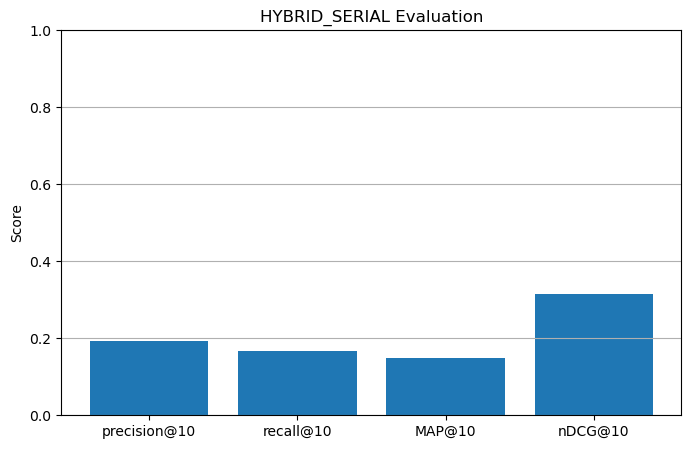

In [4]:
import matplotlib.pyplot as plt

metrics = [
    f"precision@10",
    f"recall@10",
    f"MAP@10",
    f"nDCG@10"
]

values = [
    results[m]
    for m in metrics
]

plt.figure(figsize=(8,5))

plt.bar(
    metrics,
    values
)

plt.ylim(0,1)

plt.title(
    f"{MODEL.upper()} Evaluation"
)

plt.ylabel("Score")

plt.grid(axis="y")

plt.show()

In [5]:
plt.savefig(
    f"../results/{MODEL}.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>